In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('✅ Imports klara')

✅ Imports klara


# 🎮 Video Game Sales — Unsupervised ML Lab
## Notebook 01 — Data Cleaning & Exploratory Data Analysis

**Mål med denna notebook:**
- Ladda och förstå datasetet
- Identifiera och hantera saknade värden
- Utforska fördelningar, relationer och mönster
- Förbereda data inför klustring

---

## 1. Ladda data

Datasetet kommer från [Kaggle — Video Game Sales with Ratings](https://www.kaggle.com/datasets/rush4ratio/video-game-sales-with-ratings).  
Se till att filen ligger i mappen `data/` och är döpt till `vgsales.csv`.

**Kolumner i datasetet:**
| Kolumn | Beskrivning |
|---|---|
| `Name` | Spelets titel |
| `Platform` | Konsol/plattform |
| `Year_of_Release` | Utgivningsår |
| `Genre` | Genre |
| `Publisher` | Utgivare |
| `NA_Sales` | Nordamerika (miljoner) |
| `EU_Sales` | Europa (miljoner) |
| `JP_Sales` | Japan (miljoner) |
| `Other_Sales` | Övriga världen (miljoner) |
| `Global_Sales` | Total global försäljning (miljoner) |
| `Critic_Score` | Metacritic-poäng (0–100) |
| `Critic_Count` | Antal kritikerrecensioner |
| `User_Score` | Användarpoäng (0–10, lagras som string!) |
| `User_Count` | Antal användarrecensioner |
| `Developer` | Utvecklare |
| `Rating` | ESRB-klassificering |

In [4]:
df_raw = pd.read_csv('../data/vgsales.csv')

print(f'Rader:    {df_raw.shape[0]:,}')
print(f'Kolumner: {df_raw.shape[1]}')
df_raw.head(10)

Rader:    16,719
Kolumner: 16


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26,NaN,NaN,NaN,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.28,9.14,6.50,2.88,29.80,89.0,65.0,8.5,431.0,Nintendo,E
7,Wii Play,Wii,2006.0,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92,58.0,41.0,6.6,129.0,Nintendo,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.44,6.94,4.70,2.24,28.32,87.0,80.0,8.4,594.0,Nintendo,E
9,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Datarengöring

Innan vi kan analysera behöver vi förstå vad som saknas och åtgärda det.  
Vi börjar med en överblick av kolumntyper och saknade värden.

In [5]:
print('=== Kolumntyper ===')
df_raw.info()
print()
print('=== Saknade värden per kolumn ===')
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
pd.DataFrame({'Saknas': missing, 'Procent (%)': missing_pct})[missing > 0]

=== Kolumntyper ===
<class 'pandas.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  str    
 1   Platform         16719 non-null  str    
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  str    
 4   Publisher        16665 non-null  str    
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  str    
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  str    
 15  Rating           9950 non-null   str    
dtypes: float64(9), str(7)
memory usage: 2.0 MB

=== S

,Saknas,Procent (%)
Name,2,0.0
Year_of_Release,269,1.6
Genre,2,0.0
Publisher,54,0.3
Critic_Score,8582,51.3
Critic_Count,8582,51.3
User_Score,6704,40.1
User_Count,9129,54.6
Developer,6623,39.6
Rating,6769,40.5


### 🔍 Observationer

| Kolumn | Saknas | Notering |
|---|---|---|
| `Critic_Score` | 51% | Mer än hälften saknar kritikerbetyg |
| `User_Count` | 55% | Mest saknad kolumn |
| `User_Score` | 40% | Lagras som **string** — innehåller `'tbd'`! |
| `Developer` | 40% | Kan ignoreras i klustring |
| `Rating` | 40% | ESRB-klassificering |
| `Year_of_Release` | 1.6% | Litet bortfall, droppar vi |
| `Publisher` | 0.3% | Litet bortfall, droppar vi |

**Viktiga slutsatser:**
- Vi kan **inte** använda betygskolumner för alla spel — vi arbetar i delmängder
- `User_Score` måste konverteras från string till float
- Försäljningskolumnerna är helt kompletta ✅

In [6]:
df = df_raw.copy()

# Droppa rader utan Year_of_Release eller Publisher
before = len(df)
df.dropna(subset=['Year_of_Release', 'Publisher'], inplace=True)
print(f'Droppade {before - len(df)} rader (saknar Year/Publisher)')

# Year som int
df['Year_of_Release'] = df['Year_of_Release'].astype(int)

# Filtrera orimliga år och nollförsäljning
df = df[df['Year_of_Release'] >= 1980]
df = df[df['Global_Sales'] > 0]

# User_Score: 'tbd' → NaN, konvertera till float
df['User_Score'] = pd.to_numeric(df['User_Score'], errors='coerce')

# Skala User_Score till 0–100 (samma skala som Critic_Score)
df['User_Score_scaled'] = df['User_Score'] * 10

print(f'Kvar efter rengöring: {len(df):,} rader')
df.dtypes

Droppade 301 rader (saknar Year/Publisher)
Kvar efter rengöring: 16,418 rader


Name                     str
Platform                 str
Year_of_Release        int64
Genre                    str
Publisher                str
NA_Sales             float64
EU_Sales             float64
JP_Sales             float64
Other_Sales          float64
Global_Sales         float64
Critic_Score         float64
Critic_Count         float64
User_Score           float64
User_Count           float64
Developer                str
Rating                   str
User_Score_scaled    float64
dtype: object

In [7]:
# Snabbkoll — duplicerade spel?
dupes = df.duplicated(subset=['Name', 'Platform']).sum()
print(f'Duplicerade rader (Name + Platform): {dupes}')

# Snabbkoll — negativa försäljningssiffror?
sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
print('\nMin-värden per försäljningskolumn:')
print(df[sales_cols].min())

Duplicerade rader (Name + Platform): 4

Min-värden per försäljningskolumn:
NA_Sales        0.00
EU_Sales        0.00
JP_Sales        0.00
Other_Sales     0.00
Global_Sales    0.01
dtype: float64


## 3. Grundläggande statistik

Nu när data är rengjord tittar vi på fördelningar och nyckeltal.

In [8]:
sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
df[sales_cols + ['Critic_Score', 'User_Score_scaled']].describe().round(2)

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,User_Score_scaled
count,16418.00,16418.00,16418.00,16418.00,16418.00,7982.00,7461.00
mean,0.26,0.15,0.08,0.05,0.54,69.00,71.27
std,0.82,0.51,0.31,0.19,1.56,13.92,14.99
min,0.00,0.00,0.00,0.00,0.01,13.00,0.00
25%,0.00,0.00,0.00,0.00,0.06,60.00,64.00
50%,0.08,0.02,0.00,0.01,0.17,71.00,75.00
75%,0.24,0.11,0.04,0.03,0.47,79.00,82.00
max,41.36,28.96,10.22,10.57,82.53,98.00,97.00


In [9]:
print(f"Unika plattformar: {df['Platform'].nunique()}")
print(f"Unika genrer:      {df['Genre'].nunique()}")
print(f"Unika publishers:  {df['Publisher'].nunique()}")
print(f"År spann:          {df['Year_of_Release'].min()} – {df['Year_of_Release'].max()}")

Unika plattformar: 31
Unika genrer:      12
Unika publishers:  579
År spann:          1980 – 2020


### 🔍 Vad berättar statistiken?

| Observation | Detalj |
|---|---|
| **Median Global Sales = 0.17M** | De flesta spel säljer väldigt lite — marknaden är extremt skev |
| **Max Global Sales = 82.53M** | Wii Sports är en extrem outlier |
| **Critic medel = 69, User medel = 71** | Relativt nära varandra i genomsnitt... |
| **User_Score min = 0** | Någon har fått 0 i användarpoäng — värt att undersöka! |
| **31 plattformar, 12 genrer** | Lagom komplexitet för klustring |
| **År: 1980–2020** | 40 år av spelhistoria |
| **4 duplicerade rader** | Droppar vi i nästa steg |

---

In [10]:
# Droppa duplicater
df.drop_duplicates(subset=['Name', 'Platform'], inplace=True)
print(f'Kvar efter borttagning av duplicater: {len(df):,} rader')

# Vilket spel fick User_Score = 0?
print('\nSpel med User_Score_scaled = 0:')
print(df[df['User_Score_scaled'] == 0][['Name', 'Platform', 'Genre', 'Critic_Score', 'User_Score_scaled']])

Kvar efter borttagning av duplicater: 16,414 rader

Spel med User_Score_scaled = 0:
                                    Name Platform      Genre  Critic_Score  \
2835  My Little Pony: Pinkie Pie's Party       DS  Adventure           NaN   

      User_Score_scaled  
2835                0.0  


In [22]:
import os

os.makedirs('../outputs/figures', exist_ok=True)
print('✅ outputs/figures mapp skapad')

✅ outputs/figures mapp skapad


### 🔍 My Little Pony: Pinkie Pie's Party

Enda spelet med `User_Score = 0` — troligen en protest-röstning snarare än ett genuint betyg.  
Inget Critic Score finns heller. Vi låter den vara kvar men den kan dyka upp som outlier i DBSCAN senare!

---
## 4. EDA — Försäljning

Nu börjar vi utforska datan visuellt. Först tittar vi på hur Global Sales är fördelad.

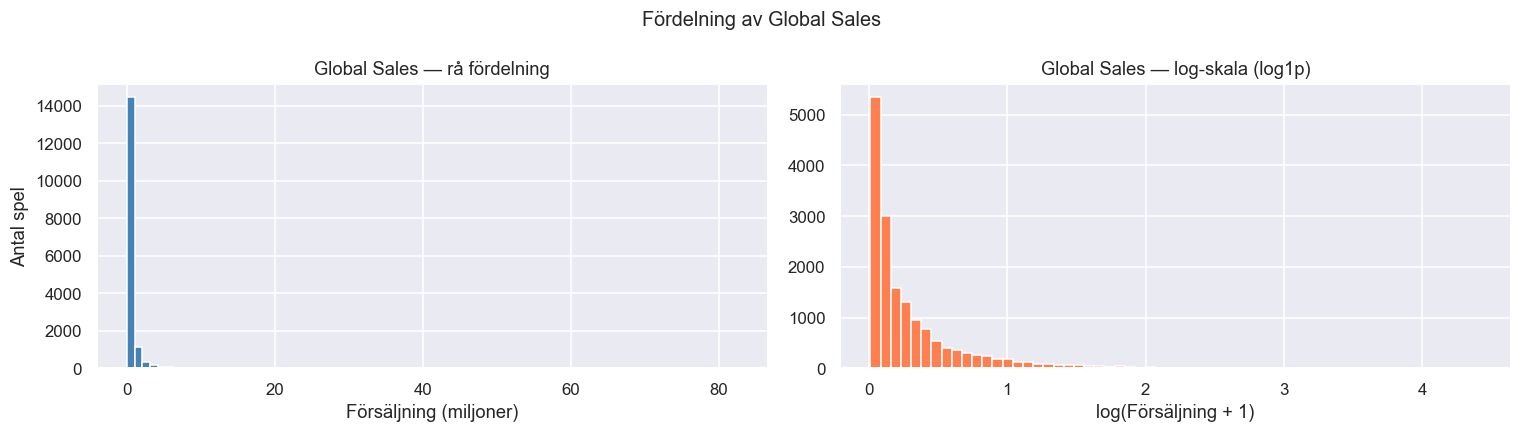

Median global sales: 0.17M
Medel  global sales: 0.54M
Max    global sales: 82.53M  (Wii Sports)


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Rå fördelning
axes[0].hist(df['Global_Sales'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Global Sales — rå fördelning')
axes[0].set_xlabel('Försäljning (miljoner)')
axes[0].set_ylabel('Antal spel')

# Log-skala
axes[1].hist(np.log1p(df['Global_Sales']), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Global Sales — log-skala (log1p)')
axes[1].set_xlabel('log(Försäljning + 1)')

plt.suptitle('Fördelning av Global Sales', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/01_sales_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Median global sales: {df["Global_Sales"].median():.2f}M')
print(f'Medel  global sales: {df["Global_Sales"].mean():.2f}M')
print(f'Max    global sales: {df["Global_Sales"].max():.2f}M  ({df.loc[df["Global_Sales"].idxmax(), "Name"]})')

### 🔍 Vad ser vi?

- **Rå fördelning:** Nästan alla spel säljer under 1M — kurvan är extremt högersnedvriden
- **Log-skala:** Avslöjar en mer normalliknande fördelning — typiskt för marknadsdata
- **Wii Sports (82.53M)** sticker ut enormt — delvis pga att det packades med Wii-konsolen
- **Median (0.17M) vs Medel (0.54M):** Stor skillnad visar att ett fåtal blockbusters drar upp snittet

> 💡 Detta är ett klassiskt **"Long Tail"**-mönster — relevant för Experiment 4!

---

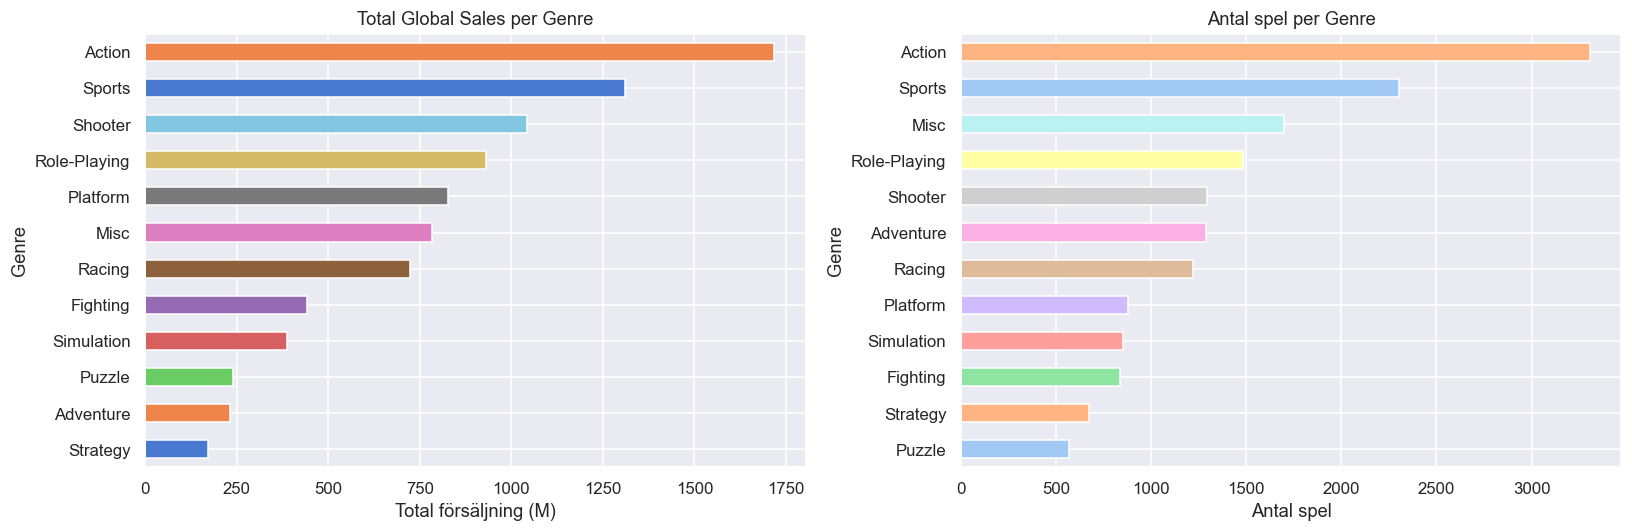

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Total försäljning per genre
genre_total = df.groupby('Genre')['Global_Sales'].sum().sort_values()
genre_total.plot(kind='barh', ax=axes[0],
                 color=sns.color_palette('muted', len(genre_total)))
axes[0].set_title('Total Global Sales per Genre')
axes[0].set_xlabel('Total försäljning (M)')

# Antal spel per genre
genre_count = df['Genre'].value_counts().sort_values()
genre_count.plot(kind='barh', ax=axes[1],
                 color=sns.color_palette('pastel', len(genre_count)))
axes[1].set_title('Antal spel per Genre')
axes[1].set_xlabel('Antal spel')

plt.tight_layout()
plt.savefig('../outputs/figures/02_sales_by_genre.png', bbox_inches='tight', dpi=150)
plt.show()

### 🔍 Vad ser vi?

| Observation | Detalj |
|---|---|
| **Action dominerar totalt** | Mest såld genre med ~1750M — men också flest spel (3000+) |
| **Shooter överpresterare** | Tredje mest sålt men bara 5:e i antal spel — hög försäljning per titel |
| **Adventure underpresterare** | Många spel men låg total försäljning — svår genre att sälja? |
| **Strategy** | Minst sålt trots att det finns många titlar |
| **Platform vs Puzzle** | Platform säljer mycket bättre trots färre titlar än Puzzle |

> 💡 **Intressant för klustring:** Försäljning per genre är *inte* proportionell mot antal spel.  
> Vissa genrer har få men extremt lönsamma titlar (Shooter, Sports).

---

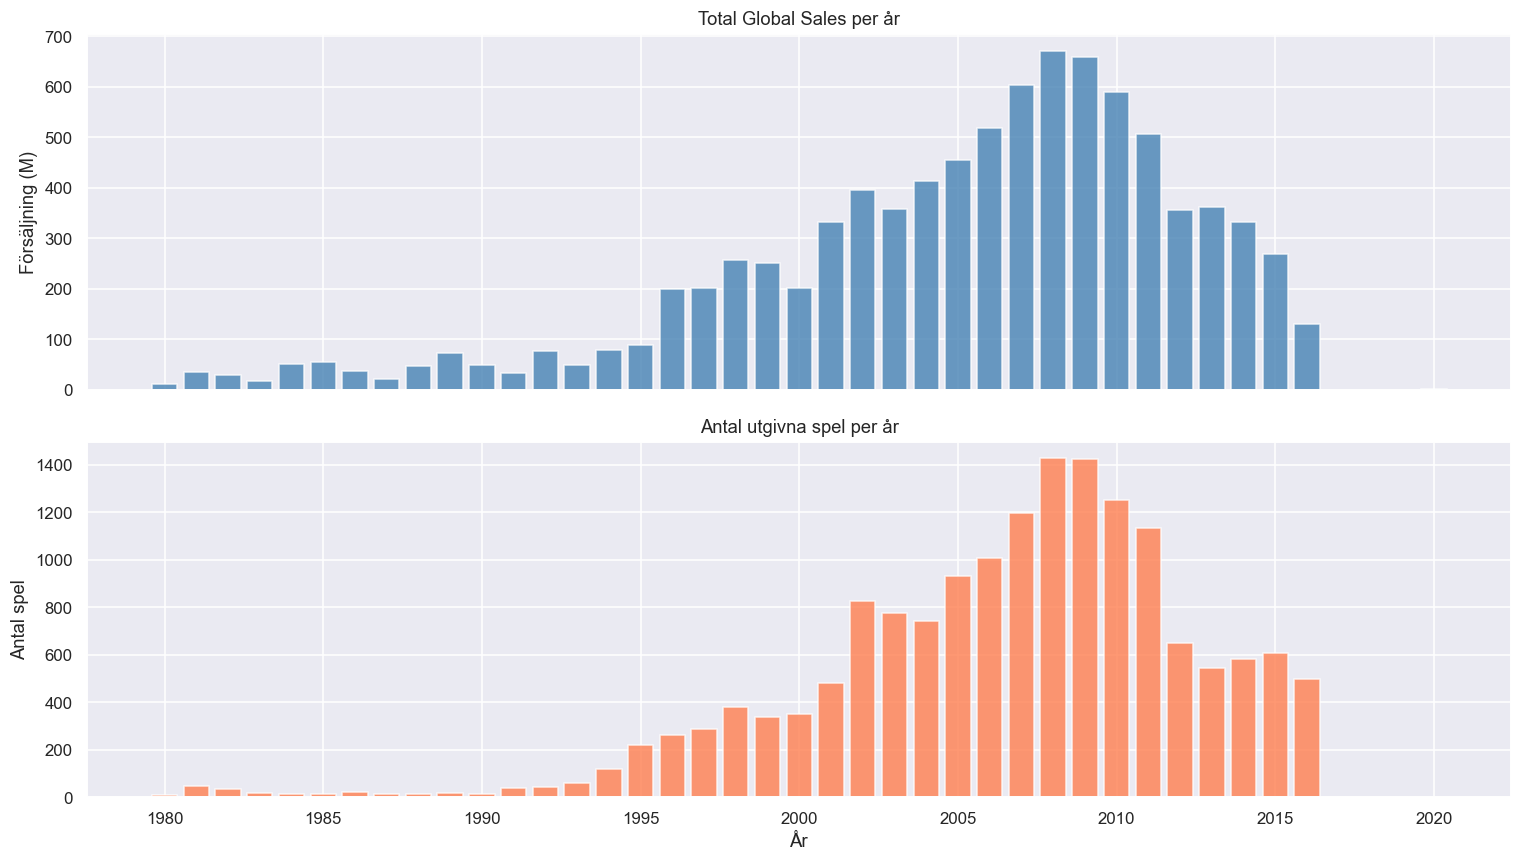

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Total försäljning per år
year_sales = df.groupby('Year_of_Release')['Global_Sales'].sum()
axes[0].bar(year_sales.index, year_sales.values, color='steelblue', alpha=0.8)
axes[0].set_title('Total Global Sales per år')
axes[0].set_ylabel('Försäljning (M)')

# Antal titlar per år
year_count = df.groupby('Year_of_Release')['Name'].count()
axes[1].bar(year_count.index, year_count.values, color='coral', alpha=0.8)
axes[1].set_title('Antal utgivna spel per år')
axes[1].set_ylabel('Antal spel')
axes[1].set_xlabel('År')

plt.tight_layout()
plt.savefig('../outputs/figures/03_sales_over_time.png', bbox_inches='tight', dpi=150)
plt.show()

### 🔍 Vad ser vi?

| Observation | Detalj |
|---|---|
| **Peak 2008–2009** | Både flest spel OCH högst försäljning — Wii-eran på topp |
| **Snabb tillväxt 1994–2008** | Industrin exploderade med PlayStation-generationen |
| **Nedgång efter 2009** | Fysisk försäljning minskar — digital distribution tar över |
| **2017–2020 ser låg ut** | Troligt datainsamlingsproblem — datasetet är från 2016 |
| **1980–1993 nästan obefintligt** | Få titlar registrerade från retro-eran |

> 💡 **Viktigt för klustring:** Vi bör vara medvetna om att data efter 2015  
> är ofullständig — kan påverka resultat om vi inkluderar nyare spel.

---

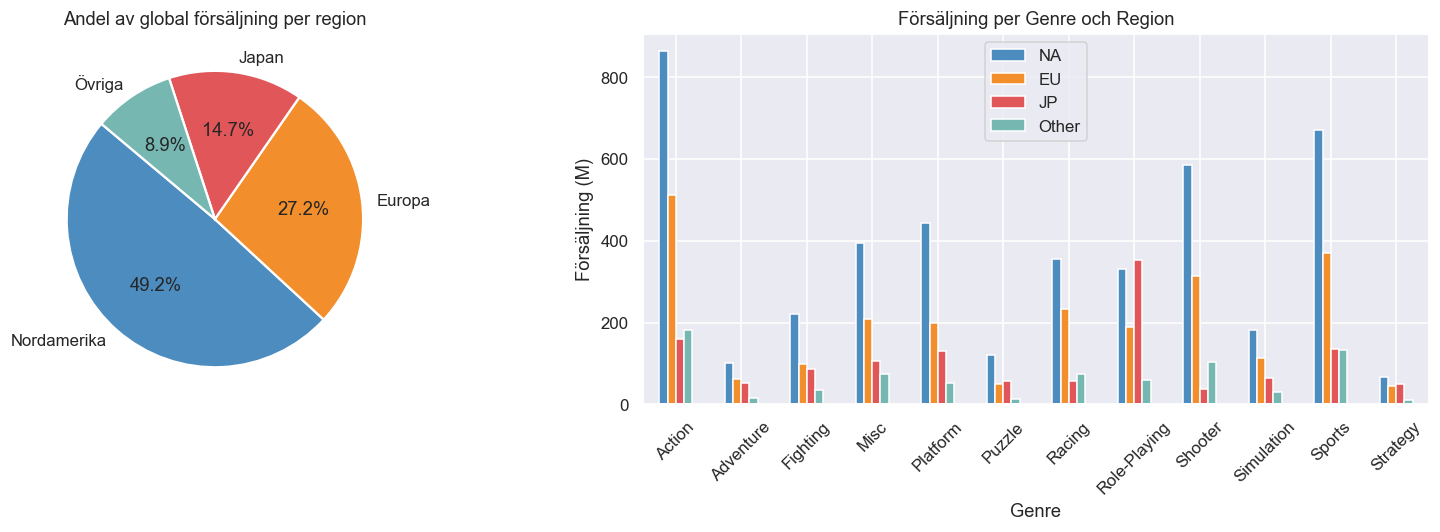

In [26]:
# Regionala andelar — pie chart + genre per region
region_totals = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
labels = ['Nordamerika', 'Europa', 'Japan', 'Övriga']
colors = ['#4c8cbf', '#f28e2b', '#e15759', '#76b7b2']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Pie
axes[0].pie(region_totals, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Andel av global försäljning per region')

# Genre per region
region_genre = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
region_genre.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Försäljning per Genre och Region')
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('Försäljning (M)')
axes[1].legend(['NA', 'EU', 'JP', 'Other'])
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/figures/04_regional_sales.png', bbox_inches='tight', dpi=150)
plt.show()

### 🔍 Vad ser vi?

| Observation | Detalj |
|---|---|
| **NA dominerar totalt** | 49.2% av all global försäljning |
| **Action = NA:s favorit** | Enormt NA-fält jämfört med övriga regioner |
| **Role-Playing = Japans genre** | JP-stapeln nästan lika hög som NA — unikt för denna genre |
| **Shooter = NA/EU** | Japan nästan obefintligt — kulturell skillnad |
| **Sports** | NA dominerar kraftigt — EU följer, JP minimal |
| **Platform** | Relativt jämnt fördelat — Nintendo är global |

> 💡 **Detta är kärnan i Experiment 1** — regionerna har fundamentalt olika  
> spelsmak. Klustring på regionala andelar borde ge tydliga segment!

---
## 5. EDA — Betyg (Critic & User Score)

Spel med både critic- och user-betyg: 6,890


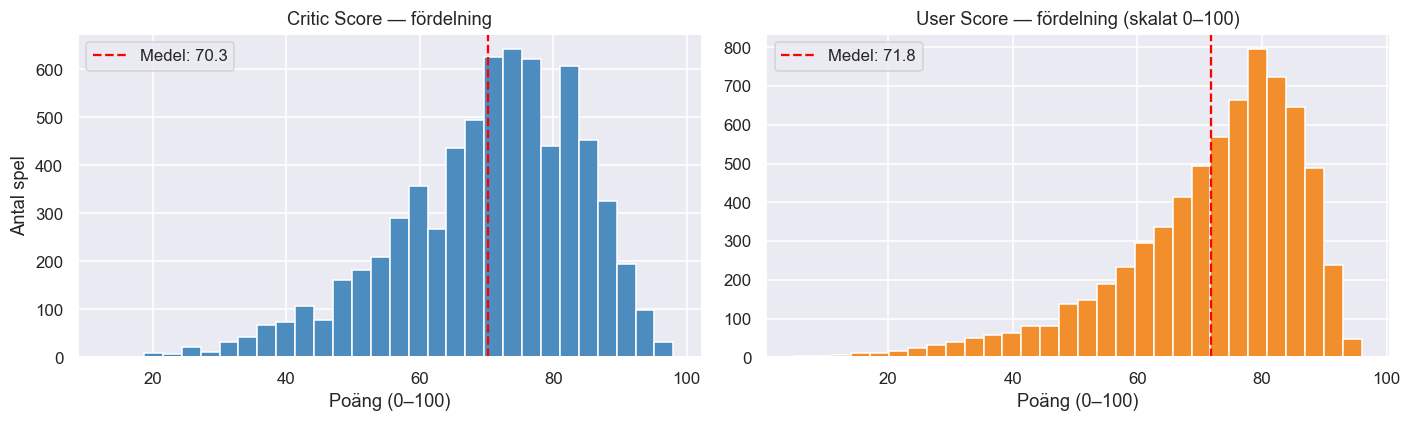

In [27]:
df_scores = df.dropna(subset=['Critic_Score', 'User_Score_scaled'])
print(f'Spel med både critic- och user-betyg: {len(df_scores):,}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_scores['Critic_Score'], bins=30,
             color='#4c8cbf', edgecolor='white')
axes[0].axvline(df_scores['Critic_Score'].mean(), color='red',
                linestyle='--', label=f"Medel: {df_scores['Critic_Score'].mean():.1f}")
axes[0].set_title('Critic Score — fördelning')
axes[0].set_xlabel('Poäng (0–100)')
axes[0].set_ylabel('Antal spel')
axes[0].legend()

axes[1].hist(df_scores['User_Score_scaled'], bins=30,
             color='#f28e2b', edgecolor='white')
axes[1].axvline(df_scores['User_Score_scaled'].mean(), color='red',
                linestyle='--', label=f"Medel: {df_scores['User_Score_scaled'].mean():.1f}")
axes[1].set_title('User Score — fördelning (skalat 0–100)')
axes[1].set_xlabel('Poäng (0–100)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/figures/05_score_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

### 🔍 Vad ser vi?

| Observation | Detalj |
|---|---|
| **Critic medel: 70.3** | Klockkurva — kritiker sprider sina betyg jämnare |
| **User medel: 71.8** | Kraftigt vänstersnedvriden — användare ger oftast höga betyg |
| **Kritiker ger låga betyg** | Tydlig svans ner mot 20–40 — kritiker är hårdare |
| **Få användare ger låga betyg** | Under 50 är ovanligt — folk spelar det de gillar |
| **6,890 spel med båda betygen** | Bara ~42% av datasetet — viktigt att ha i åtanke |

> 💡 Dessa olika beteenden gör critic vs user-jämförelsen extra intressant för Experiment 2!

---

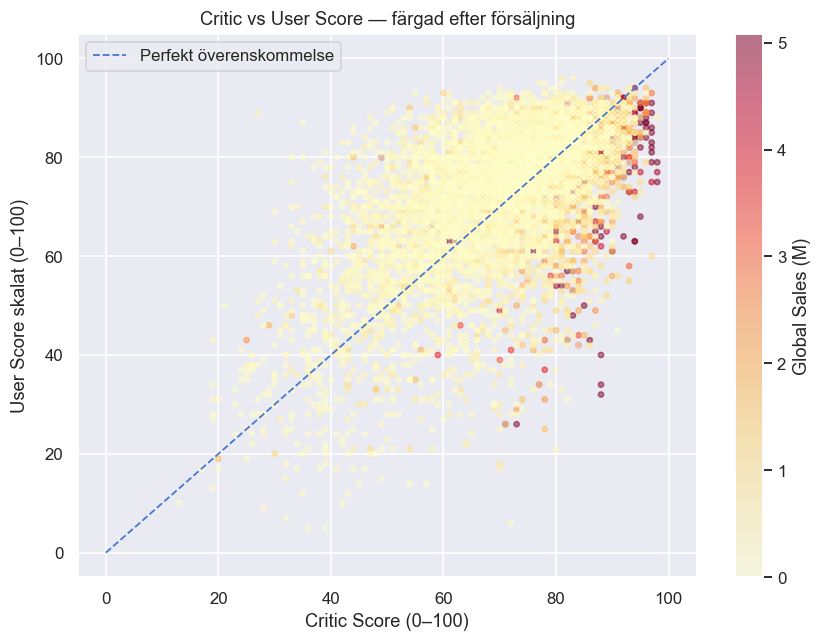

Pearson-korrelation Critic vs User: 0.580


In [28]:
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    df_scores['Critic_Score'],
    df_scores['User_Score_scaled'],
    c=df_scores['Global_Sales'],
    cmap='YlOrRd',
    s=12,
    alpha=0.5,
    norm=plt.Normalize(0, df_scores['Global_Sales'].quantile(0.98))
)

plt.colorbar(scatter, ax=ax, label='Global Sales (M)')
ax.plot([0, 100], [0, 100], 'b--', linewidth=1.2, label='Perfekt överenskommelse')
ax.set_xlabel('Critic Score (0–100)')
ax.set_ylabel('User Score skalat (0–100)')
ax.set_title('Critic vs User Score — färgad efter försäljning')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/06_critic_vs_user.png', bbox_inches='tight', dpi=150)
plt.show()

corr = df_scores[['Critic_Score', 'User_Score_scaled']].corr().iloc[0, 1]
print(f'Pearson-korrelation Critic vs User: {corr:.3f}')

### 🔍 Vad ser vi?

| Observation | Detalj |
|---|---|
| **Korrelation: 0.58** | Måttlig — kritiker och spelare är ungefär överens, men inte alltid |
| **Molnet ligger ovanför diagonalen** | Användare ger generellt högre betyg än kritiker |
| **Höga betyg = höga försäljning** | Mörkaste punkterna (mest sålda) klustrar uppe till höger |
| **Stor spridning vid critic 60–80** | Här är oenigheten störst — intressant zone för DBSCAN |
| **Outliers under diagonalen** | Kritiker gillar dessa mer än spelare — kontroversiella titlar |

> 💡 Den stora spridningen gör detta dataset perfekt för Experiment 2 —  
> DBSCAN kommer hitta de verkligt kontroversiella spelen!

---

In [17]:
df_scores = df_scores.copy()
df_scores['Score_gap'] = df_scores['Critic_Score'] - df_scores['User_Score_scaled']

print('=== Kritiker gillar MER än spelare (top 10) ===')
print(df_scores.sort_values('Score_gap', ascending=False)[
    ['Name', 'Genre', 'Critic_Score', 'User_Score_scaled', 'Score_gap']
].head(10).to_string(index=False))

print()
print('=== Spelare gillar MER än kritiker (top 10) ===')
print(df_scores.sort_values('Score_gap')[
    ['Name', 'Genre', 'Critic_Score', 'User_Score_scaled', 'Score_gap']
].head(10).to_string(index=False))

=== Kritiker gillar MER än spelare (top 10) ===
                          Name        Genre  Critic_Score  User_Score_scaled  Score_gap
    Thrillville: Off the Rails     Strategy          72.0                6.0       66.0
           Company of Heroes 2     Strategy          80.0               21.0       59.0
Call of Duty: Modern Warfare 3      Shooter          88.0               32.0       56.0
Call of Duty: Modern Warfare 3      Shooter          88.0               34.0       54.0
    Thrillville: Off the Rails     Strategy          70.0               17.0       53.0
Call of Duty: Modern Warfare 3      Shooter          78.0               25.0       53.0
Call of Duty: Modern Warfare 3      Shooter          70.0               18.0       52.0
         Football Manager Live       Sports          82.0               31.0       51.0
                    Diablo III Role-Playing          88.0               40.0       48.0
     Skylanders: SuperChargers       Action          81.0               

### 🔍 De mest kontroversiella spelen

**Kritiker > Spelare (störst gap):**
| Spel | Vad hände? |
|---|---|
| **Call of Duty: MW3** | Review-bombed av spelare — trött på franchisen |
| **Diablo III** | Alltid online-krav vid launch — spelarna rasade |
| **Company of Heroes 2** | Kontroversiell historisk framställning |

**Spelare > Kritiker (störst gap):**
| Spel | Vad hände? |
|---|---|
| **Shrek Swamp Kart Speedway** | Nostalgi-röstning eller ironi? User score 89! |
| **Antz Extreme Racing** | Klassisk barndomsnostalgi > kritikeromdöme |
| **Buffy the Vampire Slayer** | Kultfandom röstar upp det kritiker underskattade |

> 💡 **Story-vinkel:** "Vem ska du lita på — journalisten eller folket?"  
> Svaret verkar bero på om det är en stor franchise eller ett nostalgispel.

---
## 6. Korrelationsanalys

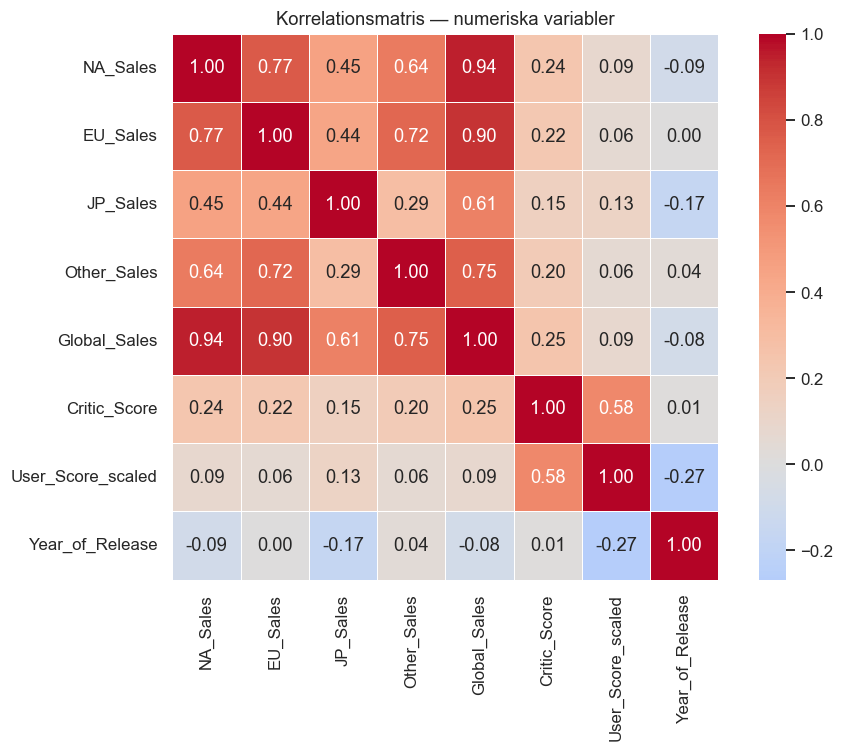

In [29]:
num_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales',
            'Global_Sales', 'Critic_Score', 'User_Score_scaled', 'Year_of_Release']

corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Korrelationsmatris — numeriska variabler')
plt.tight_layout()
plt.savefig('../outputs/figures/07_correlation_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

### 🔍 Vad ser vi i korrelationsmatrisen?

| Par | Korrelation | Tolkning |
|---|---|---|
| **NA ↔ EU** | 0.77 | Starka marknader som rör sig tillsammans |
| **NA ↔ JP** | 0.45 | Svagare — Japan är en egen marknad |
| **EU ↔ JP** | 0.44 | Samma sak — Japan följer inte väst |
| **Critic ↔ User** | 0.58 | Måttlig — vi sett detta redan |
| **Critic ↔ Global Sales** | 0.25 | Betyg förklarar lite av försäljning — men inte mycket! |
| **User ↔ Global Sales** | 0.09 | Nästan ingen koppling alls |
| **Year ↔ User Score** | -0.27 | Äldre spel får högre user score — nostalgi-effekt? |
| **Year ↔ JP Sales** | -0.17 | Japan sålde proportionellt mer förr |

> 💡 **Viktigaste insikten:** Högt betyg = inte automatiskt hög försäljning.  
> Och Japan är tydligt en separat marknad — perfekt grund för Experiment 1!

---
## 7. Topp 10 — Spel, Publishers & Plattformar

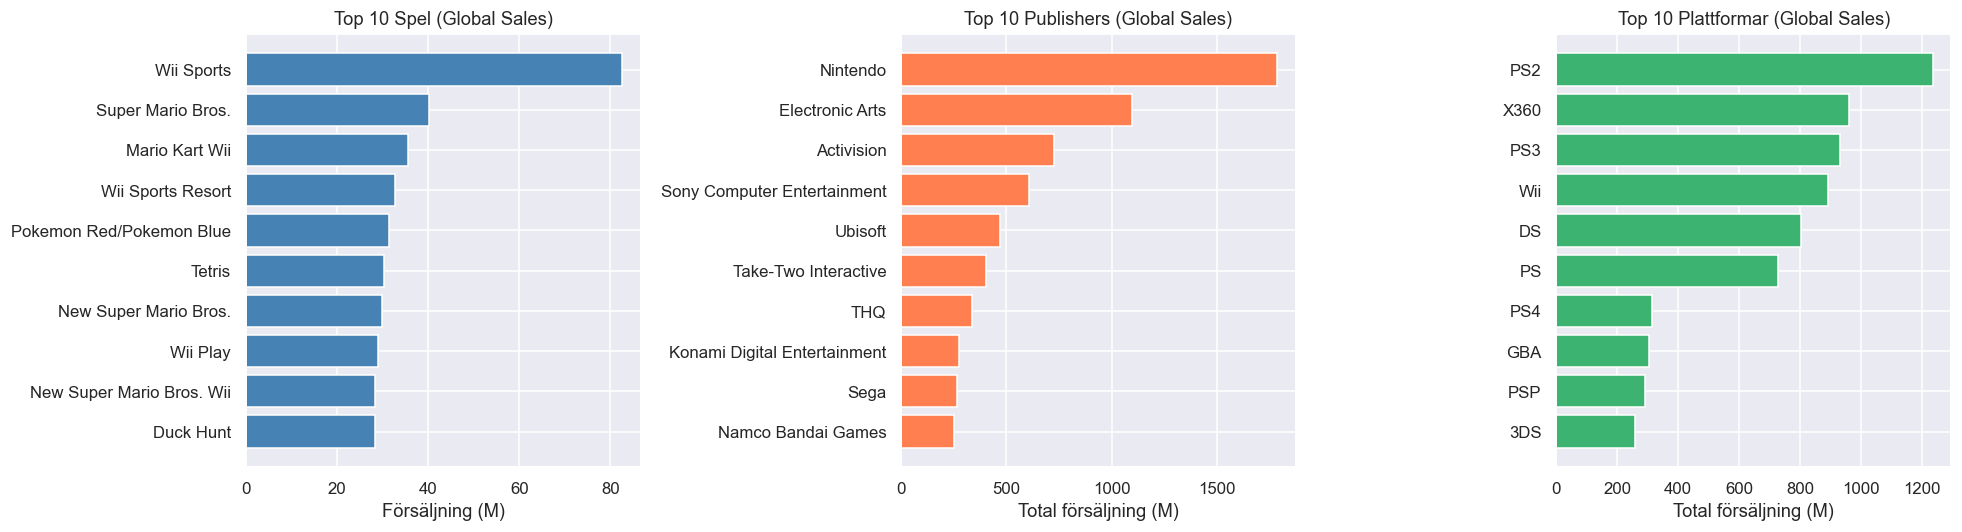

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Top 10 spel
top_games = df.nlargest(10, 'Global_Sales')[['Name', 'Global_Sales']]
axes[0].barh(top_games['Name'], top_games['Global_Sales'], color='steelblue')
axes[0].set_title('Top 10 Spel (Global Sales)')
axes[0].set_xlabel('Försäljning (M)')
axes[0].invert_yaxis()

# Top 10 publishers
top_pub = df.groupby('Publisher')['Global_Sales'].sum().nlargest(10)
axes[1].barh(top_pub.index, top_pub.values, color='coral')
axes[1].set_title('Top 10 Publishers (Global Sales)')
axes[1].set_xlabel('Total försäljning (M)')
axes[1].invert_yaxis()

# Top 10 plattformar
top_plat = df.groupby('Platform')['Global_Sales'].sum().nlargest(10)
axes[2].barh(top_plat.index, top_plat.values, color='mediumseagreen')
axes[2].set_title('Top 10 Plattformar (Global Sales)')
axes[2].set_xlabel('Total försäljning (M)')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/figures/08_top10_overview.png', bbox_inches='tight', dpi=150)
plt.show()

### 🔍 Vad ser vi?

| Observation | Detalj |
|---|---|
| **Wii Sports (82.53M)** | Nästan dubbelt så mycket som #2 — packades med konsolen |
| **Nintendo dominerar spel-listan** | 8 av 10 topspel är Nintendo-titlar |
| **Nintendo vs EA** | Nintendo ~1700M, EA ~1100M — stort gap till #3 |
| **PS2 = störst plattform** | Trots att den är gammal — enorm spelkatalog |
| **PS4 lågt** | Datasetet slutar 2016 — PS4 hade inte hunnit mogna |

> 💡 Nintendo-dominansen i topplistorna är intressant —  
> men i klustring kan vi se om deras spel faktiskt bildar egna segment.

---
## 8. Sammanfattning & Nästa steg

### Vad vi hittade i EDA:

| Fynd | Betydelse för klustring |
|---|---|
| Extremt skev försäljningsfördelning | Log-transformering kan behövas |
| Japan är en separat marknad | Regionala ratios → tydliga kluster |
| Critic ≠ User score alltid | DBSCAN hittar kontroversiella spel |
| Betyg förklarar lite av försäljning | Intressant att utforska vidare |
| Nintendo-dominans i topp | Kan bilda eget kluster |

### Nästa steg:
➡️ `02_feature_engineering.ipynb` — Regionala ratios, encodning, plattformsgenerationer

In [20]:
df.to_csv('../data/vgsales_clean.csv', index=False)
print(f'✅ Sparat vgsales_clean.csv ({len(df):,} rader)')

✅ Sparat vgsales_clean.csv (16,414 rader)
